# Task 3: Event Impact Modeling

## Forecasting Financial Inclusion in Ethiopia

This notebook models how financial-sector events—including product launches, policy reforms, infrastructure investments, market entries, and regulatory changes—may influence financial inclusion indicators in Ethiopia.

### Objectives

1. Load and validate the enriched financial inclusion dataset.
2. Join impact-link records with their parent events.
3. Summarize which events affect which indicators.
4. Build an event–indicator association matrix.
5. Model delayed event effects using documented implementation lags.
6. Compare modeled event effects with available historical observations.
7. Document assumptions, validation results, and uncertainty.

Events remain pillar-neutral in the unified dataset. Their potential effects on Access, Usage, Affordability, Gender, and other dimensions are represented through the associated `impact_link` records.

In [20]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.grid"] = True

In [21]:
def validate_required_columns(
    dataframe,
    required_columns,
    dataframe_name="DataFrame"
):
    """
    Confirm that a DataFrame contains all required columns.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        DataFrame to validate.
    required_columns : list
        Columns required for the analysis.
    dataframe_name : str
        Descriptive name used in error messages.

    Raises
    ------
    TypeError
        If dataframe is not a pandas DataFrame.
    ValueError
        If required columns are missing.
    """
    if not isinstance(dataframe, pd.DataFrame):
        raise TypeError(
            f"{dataframe_name} must be a pandas DataFrame."
        )

    missing_columns = [
        column
        for column in required_columns
        if column not in dataframe.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{dataframe_name} is missing required columns: "
            f"{missing_columns}"
        )

    return True

In [22]:
current_path = Path.cwd()

if current_path.name == "notebooks":
    project_root = current_path.parent
else:
    project_root = current_path

data_path = (
    project_root
    / "data"
    / "processed"
    / "ethiopia_fi_enriched.csv"
)

figures_path = (
    project_root
    / "reports"
    / "figures"
)

models_path = project_root / "models"

figures_path.mkdir(parents=True, exist_ok=True)
models_path.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)
print("Dataset exists:", data_path.exists())
print("Figures directory:", figures_path)
print("Models directory:", models_path)


Project root: c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast
Dataset exists: True
Figures directory: c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\reports\figures
Models directory: c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\models


In [46]:
from pathlib import Path

figures_path = Path("figures")
figures_path.mkdir(exist_ok=True)

def save_figure(filename):
    """
    Save the current matplotlib figure.
    """
    output_path = figures_path / filename

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    return output_path

In [23]:
if not data_path.exists():
    raise FileNotFoundError(
        f"Enriched dataset was not found at: {data_path}"
    )

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (58, 35)


,category,collected_by,collection_date,comparable_country,confidence,evidence_basis,fiscal_year,gender,impact_direction,impact_estimate,impact_magnitude,indicator,indicator_code,indicator_direction,lag_months,location,notes,observation_date,original_text,parent_id,period_end,period_start,pillar,record_id,record_type,region,related_indicator,relationship_type,source_name,source_type,source_url,unit,value_numeric,value_text,value_type
0,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2014,all,NaN,NaN,NaN,Account Ownership Rate,ACC_OWNERSHIP,higher_better,NaN,national,NaN,2014-12-31,Baseline year,NaN,NaN,NaN,ACCESS,REC_0001,observation,NaN,NaN,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,%,22.0,NaN,percentage
1,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2017,all,NaN,NaN,NaN,Account Ownership Rate,ACC_OWNERSHIP,higher_better,NaN,national,NaN,2017-12-31,NaN,NaN,NaN,NaN,ACCESS,REC_0002,observation,NaN,NaN,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,%,35.0,NaN,percentage
2,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2021,all,NaN,NaN,NaN,Account Ownership Rate,ACC_OWNERSHIP,higher_better,NaN,national,NaN,2021-12-31,NaN,NaN,NaN,NaN,ACCESS,REC_0003,observation,NaN,NaN,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,%,46.0,NaN,percentage
3,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2021,male,NaN,NaN,NaN,Account Ownership Rate,ACC_OWNERSHIP,higher_better,NaN,national,NaN,2021-12-31,Gender disaggregated,NaN,NaN,NaN,ACCESS,REC_0004,observation,NaN,NaN,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,%,56.0,NaN,percentage
4,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2021,female,NaN,NaN,NaN,Account Ownership Rate,ACC_OWNERSHIP,higher_better,NaN,national,NaN,2021-12-31,Gender disaggregated,NaN,NaN,NaN,ACCESS,REC_0005,observation,NaN,NaN,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,%,36.0,NaN,percentage


In [37]:
required_columns = [
    "record_id",
    "parent_id",
    "record_type",
    "category",
    "pillar",
    "indicator",
    "indicator_code",
    "related_indicator",
    "impact_direction",
    "impact_magnitude",
    "impact_estimate",
    "lag_months",
    "confidence",
    "evidence_basis",
    "period_start",
    "observation_date",
    "value_numeric"
]

validate_required_columns(
    df,
    required_columns,
    dataframe_name="Enriched financial inclusion dataset"
)

print("Task 3 required-column validation passed.")

Task 3 required-column validation passed.


In [38]:
date_columns = [
    "period_start",
    "period_end",
    "observation_date",
    "collection_date"
]

for column in date_columns:
    if column in df.columns:
        df[column] = pd.to_datetime(
            df[column],
            format="mixed",
            errors="coerce"
        )


def clean_numeric_column(series):
    """
    Convert numeric-like values to floats.

    Handles percentage signs, commas, spaces,
    and other non-numeric characters.
    """
    cleaned = (
        series
        .astype("string")
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.extract(
            r"(-?\d+(?:\.\d+)?)",
            expand=False
        )
    )

    return pd.to_numeric(
        cleaned,
        errors="coerce"
    )


df["value_numeric"] = clean_numeric_column(
    df["value_numeric"]
)

df["impact_estimate"] = clean_numeric_column(
    df["impact_estimate"]
)

df["lag_months"] = clean_numeric_column(
    df["lag_months"]
)

print("Date and numeric conversion completed.")

Date and numeric conversion completed.


In [39]:
impact_estimate_check = df[
    df["record_type"] == "impact_link"
][
    [
        "record_id",
        "parent_id",
        "related_indicator",
        "impact_direction",
        "impact_magnitude",
        "impact_estimate",
        "lag_months"
    ]
]

display(impact_estimate_check)

print(
    "Valid numerical impact estimates:",
    impact_estimate_check[
        "impact_estimate"
    ].notna().sum()
)

print(
    "Missing numerical impact estimates:",
    impact_estimate_check[
        "impact_estimate"
    ].isna().sum()
)

,record_id,parent_id,related_indicator,impact_direction,impact_magnitude,impact_estimate,lag_months
43,IMP_0001,EVT_0001,ACC_OWNERSHIP,increase,<NA>,15.0,12.0
44,IMP_0002,EVT_0001,USG_TELEBIRR_USERS,increase,<NA>,<NA>,3.0
45,IMP_0003,EVT_0001,USG_P2P_COUNT,increase,<NA>,25.0,6.0
46,IMP_0004,EVT_0002,ACC_4G_COV,increase,<NA>,15.0,12.0
47,IMP_0005,EVT_0002,AFF_DATA_INCOME,decrease,<NA>,-20.0,12.0
48,IMP_0006,EVT_0003,USG_MPESA_USERS,increase,<NA>,<NA>,3.0
49,IMP_0007,EVT_0003,ACC_MM_ACCOUNT,increase,<NA>,5.0,6.0
50,IMP_0008,EVT_0004,ACC_OWNERSHIP,increase,<NA>,10.0,24.0
51,IMP_0009,EVT_0004,GEN_GAP_ACC,decrease,<NA>,-5.0,24.0
52,IMP_0010,EVT_0005,AFF_DATA_INCOME,increase,<NA>,30.0,3.0


Valid numerical impact estimates: 12
Missing numerical impact estimates: 2


In [27]:
events = df[
    df["record_type"] == "event"
].copy()

impact_links = df[
    df["record_type"] == "impact_link"
].copy()

observations = df[
    df["record_type"] == "observation"
].copy()

targets = df[
    df["record_type"] == "target"
].copy()

record_summary = pd.DataFrame({
    "record_type": [
        "events",
        "impact_links",
        "observations",
        "targets"
    ],
    "record_count": [
        len(events),
        len(impact_links),
        len(observations),
        len(targets)
    ]
})

record_summary

,record_type,record_count
0,events,10
1,impact_links,14
2,observations,31
3,targets,3


In [28]:
event_ids = set(events["record_id"].dropna())
parent_ids = set(impact_links["parent_id"].dropna())

unmatched_parent_ids = sorted(
    parent_ids - event_ids
)

print(
    "Impact links with unmatched parent events:",
    len(unmatched_parent_ids)
)

if unmatched_parent_ids:
    display(
        impact_links[
            impact_links["parent_id"].isin(
                unmatched_parent_ids
            )
        ]
    )
else:
    print(
        "All impact links are connected to valid events."
    )

Impact links with unmatched parent events: 0
All impact links are connected to valid events.


## 1. Event and Impact-Link Preparation

The unified schema stores events independently from the financial inclusion pillars. An event may influence multiple indicators and pillars, so the event records are joined to the `impact_link` records through `parent_id`.

Each impact link provides:

- the affected indicator,
- the affected pillar,
- the expected direction,
- the estimated magnitude,
- the implementation lag,
- the confidence level,
- and the evidence supporting the relationship.

In [29]:
event_details = events[
    [
        "record_id",
        "indicator",
        "category",
        "period_start",
        "original_text",
        "source_name",
        "source_url"
    ]
].rename(
    columns={
        "record_id": "event_id",
        "indicator": "event_name",
        "category": "event_category",
        "period_start": "event_date",
        "original_text": "event_description",
        "source_name": "event_source",
        "source_url": "event_source_url"
    }
)

event_impact_data = impact_links.merge(
    event_details,
    left_on="parent_id",
    right_on="event_id",
    how="left",
    validate="many_to_one"
)

print(
    "Joined event-impact records:",
    len(event_impact_data)
)

event_impact_data[
    [
        "parent_id",
        "event_name",
        "event_category",
        "pillar",
        "related_indicator",
        "impact_direction",
        "impact_magnitude",
        "lag_months",
        "confidence"
    ]
].sort_values(
    [
        "event_name",
        "related_indicator"
    ]
)

Joined event-impact records: 14


,parent_id,event_name,event_category,pillar,related_indicator,impact_direction,impact_magnitude,lag_months,confidence
12,EVT_0008,EthioPay Instant Payment System Launch,infrastructure,USAGE,USG_P2P_COUNT,increase,<NA>,6.0,medium
7,EVT_0004,Fayda Digital ID Program Rollout,infrastructure,ACCESS,ACC_OWNERSHIP,increase,<NA>,24.0,medium
8,EVT_0004,Fayda Digital ID Program Rollout,infrastructure,GENDER,GEN_GAP_ACC,decrease,<NA>,24.0,medium
9,EVT_0005,Foreign Exchange Liberalization,policy,AFFORDABILITY,AFF_DATA_INCOME,increase,<NA>,3.0,high
10,EVT_0007,M-Pesa EthSwitch Integration,partnership,USAGE,USG_MPESA_ACTIVE,increase,<NA>,3.0,medium
11,EVT_0007,M-Pesa EthSwitch Integration,partnership,USAGE,USG_P2P_COUNT,increase,<NA>,3.0,medium
6,EVT_0003,M-Pesa Ethiopia Launch,product_launch,ACCESS,ACC_MM_ACCOUNT,increase,<NA>,6.0,medium
5,EVT_0003,M-Pesa Ethiopia Launch,product_launch,USAGE,USG_MPESA_USERS,increase,<NA>,3.0,high
3,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,ACCESS,ACC_4G_COV,increase,<NA>,12.0,medium
4,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,AFFORDABILITY,AFF_DATA_INCOME,decrease,<NA>,12.0,medium


In [40]:
direction_scores = {
    "increase": 1,
    "decrease": -1,
    "neutral": 0
}

confidence_weights = {
    "high": 1.00,
    "medium": 0.75,
    "low": 0.50
}

magnitude_weights = {
    "high": 1.00,
    "medium": 0.75,
    "low": 0.50
}

event_impact_data["direction_score"] = (
    event_impact_data["impact_direction"]
    .astype("string")
    .str.lower()
    .map(direction_scores)
)

event_impact_data["confidence_weight"] = (
    event_impact_data["confidence"]
    .astype("string")
    .str.lower()
    .map(confidence_weights)
    .fillna(0.50)
)

event_impact_data["magnitude_weight"] = (
    event_impact_data["impact_magnitude"]
    .astype("string")
    .str.lower()
    .map(magnitude_weights)
    .fillna(0.75)
)

event_impact_data["signed_estimate"] = (
    event_impact_data["impact_estimate"]
    * event_impact_data["direction_score"]
)

event_impact_data["weighted_effect"] = (
    event_impact_data["signed_estimate"]
    * event_impact_data["confidence_weight"]
    * event_impact_data["magnitude_weight"]
)

event_impact_data[
    [
        "event_name",
        "related_indicator",
        "impact_direction",
        "impact_magnitude",
        "impact_estimate",
        "confidence",
        "signed_estimate",
        "weighted_effect"
    ]
]

,event_name,related_indicator,impact_direction,impact_magnitude,impact_estimate,confidence,signed_estimate,weighted_effect
0,Telebirr Launch,ACC_OWNERSHIP,increase,<NA>,15.0,medium,15.0,8.4375
1,Telebirr Launch,USG_TELEBIRR_USERS,increase,<NA>,NaN,high,NaN,NaN
2,Telebirr Launch,USG_P2P_COUNT,increase,<NA>,25.0,medium,25.0,14.0625
3,Safaricom Ethiopia Commercial Launch,ACC_4G_COV,increase,<NA>,15.0,medium,15.0,8.4375
4,Safaricom Ethiopia Commercial Launch,AFF_DATA_INCOME,decrease,<NA>,-20.0,medium,20.0,11.2500
5,M-Pesa Ethiopia Launch,USG_MPESA_USERS,increase,<NA>,NaN,high,NaN,NaN
6,M-Pesa Ethiopia Launch,ACC_MM_ACCOUNT,increase,<NA>,5.0,medium,5.0,2.8125
7,Fayda Digital ID Program Rollout,ACC_OWNERSHIP,increase,<NA>,10.0,medium,10.0,5.6250
8,Fayda Digital ID Program Rollout,GEN_GAP_ACC,decrease,<NA>,-5.0,medium,5.0,2.8125
9,Foreign Exchange Liberalization,AFF_DATA_INCOME,increase,<NA>,30.0,high,30.0,22.5000


In [41]:
association_summary = event_impact_data[
    [
        "event_id",
        "event_name",
        "event_category",
        "event_date",
        "pillar",
        "related_indicator",
        "impact_direction",
        "impact_magnitude",
        "impact_estimate",
        "lag_months",
        "confidence",
        "weighted_effect",
        "evidence_basis"
    ]
].sort_values(
    [
        "event_date",
        "event_name",
        "related_indicator"
    ],
    na_position="last"
)

association_summary

,event_id,event_name,event_category,event_date,pillar,related_indicator,impact_direction,impact_magnitude,impact_estimate,lag_months,confidence,weighted_effect,evidence_basis
12,EVT_0008,EthioPay Instant Payment System Launch,infrastructure,NaT,USAGE,USG_P2P_COUNT,increase,<NA>,15.0,6.0,medium,8.4375,literature
7,EVT_0004,Fayda Digital ID Program Rollout,infrastructure,NaT,ACCESS,ACC_OWNERSHIP,increase,<NA>,10.0,24.0,medium,5.6250,literature
8,EVT_0004,Fayda Digital ID Program Rollout,infrastructure,NaT,GENDER,GEN_GAP_ACC,decrease,<NA>,-5.0,24.0,medium,2.8125,literature
9,EVT_0005,Foreign Exchange Liberalization,policy,NaT,AFFORDABILITY,AFF_DATA_INCOME,increase,<NA>,30.0,3.0,high,22.5000,empirical
10,EVT_0007,M-Pesa EthSwitch Integration,partnership,NaT,USAGE,USG_MPESA_ACTIVE,increase,<NA>,15.0,3.0,medium,8.4375,literature
11,EVT_0007,M-Pesa EthSwitch Integration,partnership,NaT,USAGE,USG_P2P_COUNT,increase,<NA>,10.0,3.0,medium,5.6250,literature
6,EVT_0003,M-Pesa Ethiopia Launch,product_launch,NaT,ACCESS,ACC_MM_ACCOUNT,increase,<NA>,5.0,6.0,medium,2.8125,theoretical
5,EVT_0003,M-Pesa Ethiopia Launch,product_launch,NaT,USAGE,USG_MPESA_USERS,increase,<NA>,NaN,3.0,high,NaN,empirical
3,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,NaT,ACCESS,ACC_4G_COV,increase,<NA>,15.0,12.0,medium,8.4375,empirical
4,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,NaT,AFFORDABILITY,AFF_DATA_INCOME,decrease,<NA>,-20.0,12.0,medium,11.2500,literature


In [42]:
association_matrix = event_impact_data.pivot_table(
    index="event_name",
    columns="related_indicator",
    values="weighted_effect",
    aggfunc="sum"
)

association_matrix_display = (
    association_matrix.fillna(0)
)

association_matrix_display

related_indicator,ACC_4G_COV,ACC_MM_ACCOUNT,ACC_OWNERSHIP,AFF_DATA_INCOME,GEN_GAP_ACC,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_TELEBIRR_USERS
event_name,,,,,,,,,
EthioPay Instant Payment System Launch,0.0000,0.0000,0.0000,0.00,0.0000,0.0000,0.0,8.4375,0.0
Fayda Digital ID Program Rollout,0.0000,0.0000,5.6250,0.00,2.8125,0.0000,0.0,0.0000,0.0
Foreign Exchange Liberalization,0.0000,0.0000,0.0000,22.50,0.0000,0.0000,0.0,0.0000,0.0
M-Pesa EthSwitch Integration,0.0000,0.0000,0.0000,0.00,0.0000,8.4375,0.0,5.6250,0.0
M-Pesa Ethiopia Launch,0.0000,2.8125,0.0000,0.00,0.0000,0.0000,0.0,0.0000,0.0
Safaricom Ethiopia Commercial Launch,8.4375,0.0000,0.0000,11.25,0.0000,0.0000,0.0,0.0000,0.0
Safaricom Ethiopia Price Increase,0.0000,0.0000,0.0000,7.50,0.0000,0.0000,0.0,0.0000,0.0
Telebirr Launch,0.0000,0.0000,8.4375,0.00,0.0000,0.0000,0.0,14.0625,0.0


In [33]:
association_matrix_path = (
    models_path
    / "event_indicator_association_matrix.csv"
)

association_summary_path = (
    models_path
    / "event_indicator_association_summary.csv"
)

association_matrix.to_csv(
    association_matrix_path
)

association_summary.to_csv(
    association_summary_path,
    index=False
)

print("Association matrix saved to:")
print(association_matrix_path)

print("\nAssociation summary saved to:")
print(association_summary_path)

Association matrix saved to:
c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\models\event_indicator_association_matrix.csv

Association summary saved to:
c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\models\event_indicator_association_summary.csv


TypeError: Image data of dtype object cannot be converted to float

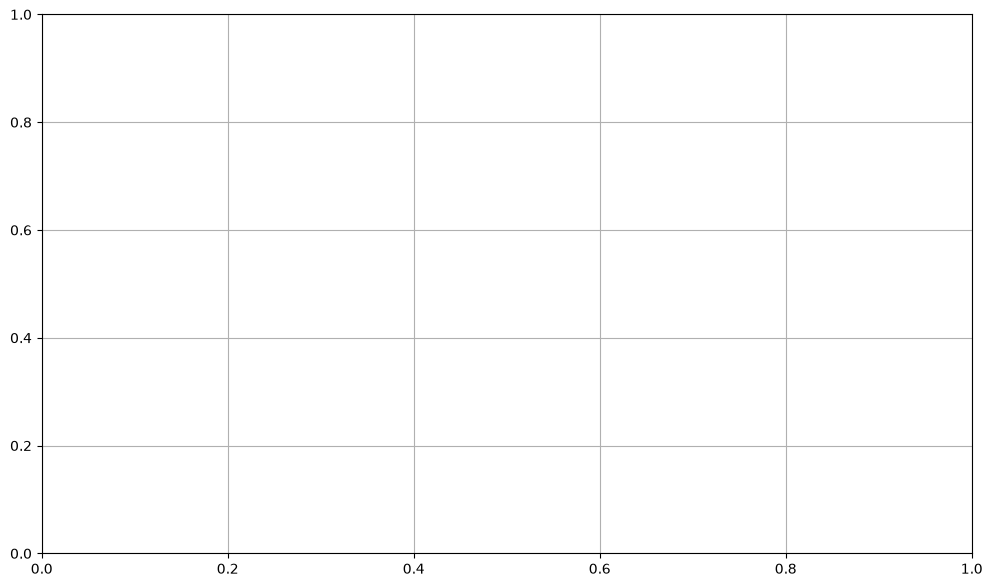

In [34]:
fig, ax = plt.subplots(
    figsize=(
        max(12, len(association_matrix.columns) * 1.2),
        max(7, len(association_matrix.index) * 0.65)
    )
)

heatmap = ax.imshow(
    association_matrix.values,
    aspect="auto"
)

ax.set_xticks(
    range(len(association_matrix.columns))
)

ax.set_xticklabels(
    association_matrix.columns,
    rotation=45,
    horizontalalignment="right"
)

ax.set_yticks(
    range(len(association_matrix.index))
)

ax.set_yticklabels(
    association_matrix.index
)

ax.set_title(
    "Event–Indicator Association Matrix"
)

ax.set_xlabel(
    "Financial Inclusion Indicator"
)

ax.set_ylabel(
    "Financial-Sector Event"
)

for row_index in range(
    len(association_matrix.index)
):
    for column_index in range(
        len(association_matrix.columns)
    ):
        value = association_matrix.iloc[
            row_index,
            column_index
        ]

        ax.text(
            column_index,
            row_index,
            f"{value:.1f}",
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=8
        )

figure_path = (
    figures_path
    / "event_indicator_association_matrix.png"
)

plt.tight_layout()
plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Figure saved to:")
print(figure_path)

### Association Matrix Interpretation

The event–indicator association matrix summarizes which financial-sector events are expected to influence each financial inclusion indicator and the estimated strength and direction of those relationships.

Positive values represent expected increases, while negative values represent expected decreases. The values are based on the documented impact magnitude and are adjusted using the confidence classification of each impact link.

A value of zero does not prove that an event has no effect. It only indicates that no explicit relationship is documented in the available impact-link dataset.

The matrix is a structured modeling input rather than a causal estimate. It will be used to construct event-adjusted scenarios and to compare documented expectations against observed historical changes.

In [43]:
commit_1_checks = {
    "dataset_loaded": not df.empty,
    "events_available": len(events) == 10,
    "impact_links_available": len(impact_links) == 14,
    "all_parent_links_valid": (
        len(unmatched_parent_ids) == 0
    ),
    "joined_records_complete": (
        len(event_impact_data) == len(impact_links)
    ),
    "impact_estimates_available": (
        event_impact_data[
            "impact_estimate"
        ].notna().any()
    ),
    "weighted_effects_available": (
        event_impact_data[
            "weighted_effect"
        ].notna().any()
    ),
    "association_matrix_created": (
        not association_matrix_display.empty
    ),
    "association_matrix_has_effects": (
        association_matrix_display
        .abs()
        .to_numpy()
        .sum() > 0
    ),
    "association_matrix_saved": (
        association_matrix_path.exists()
    ),
    "association_figure_saved": (
        figure_path.exists()
    )
}

commit_1_validation = pd.DataFrame(
    commit_1_checks.items(),
    columns=[
        "validation_check",
        "passed"
    ]
)

commit_1_validation

,validation_check,passed
0,dataset_loaded,True
1,events_available,True
2,impact_links_available,True
3,all_parent_links_valid,True
4,joined_records_complete,True
5,impact_estimates_available,True
6,weighted_effects_available,True
7,association_matrix_created,True
8,association_matrix_has_effects,True
9,association_matrix_saved,True


In [ ]:
if not commit_1_validation["passed"].all():
    failed_checks = commit_1_validation[
        ~commit_1_validation["passed"]
    ]

    display(failed_checks)

    raise ValueError(
        "Commit 1 validation failed."
    )

print(
    "All Commit 1 validation checks passed."
)

All Commit 1 validation checks passed.


## Event Impact Summary Statistics

This section summarizes the overall impact of each event, identifies the strongest positive and negative events, and prepares the data for forecasting.

In [44]:
event_summary = (
    event_impact_data
    .groupby(
        [
            "event_name",
            "event_category"
        ],
        dropna=False
    )
    .agg(
        number_of_indicators=(
            "related_indicator",
            "count"
        ),
        average_effect=(
            "weighted_effect",
            "mean"
        ),
        total_effect=(
            "weighted_effect",
            "sum"
        ),
        average_confidence=(
            "confidence_weight",
            "mean"
        )
    )
    .reset_index()
)

event_summary = event_summary.sort_values(
    "total_effect",
    ascending=False
)

event_summary

,event_name,event_category,number_of_indicators,average_effect,total_effect,average_confidence
2,Foreign Exchange Liberalization,policy,1,22.50000,22.5000,1.000000
7,Telebirr Launch,product_launch,3,11.25000,22.5000,0.833333
5,Safaricom Ethiopia Commercial Launch,market_entry,2,9.84375,19.6875,0.750000
3,M-Pesa EthSwitch Integration,partnership,2,7.03125,14.0625,0.750000
0,EthioPay Instant Payment System Launch,infrastructure,1,8.43750,8.4375,0.750000
1,Fayda Digital ID Program Rollout,infrastructure,2,4.21875,8.4375,0.750000
6,Safaricom Ethiopia Price Increase,pricing,1,7.50000,7.5000,1.000000
4,M-Pesa Ethiopia Launch,product_launch,2,2.81250,2.8125,0.875000


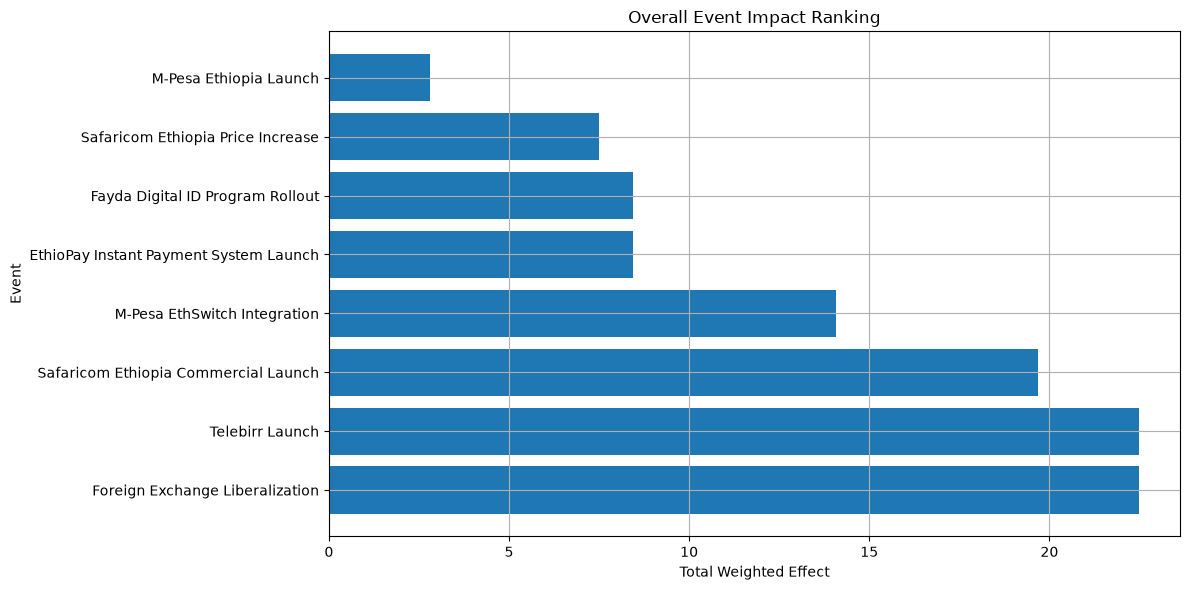

figures\event_impact_ranking.png


In [47]:
plt.figure(figsize=(12,6))

plt.barh(
    event_summary["event_name"],
    event_summary["total_effect"]
)

plt.xlabel("Total Weighted Effect")

plt.ylabel("Event")

plt.title("Overall Event Impact Ranking")

plt.tight_layout()

event_ranking_path = save_figure(
    "event_impact_ranking.png"
)

plt.show()

print(event_ranking_path)

In [48]:
indicator_summary = (
    event_impact_data
    .groupby(
        "related_indicator"
    )
    .agg(
        average_effect=(
            "weighted_effect",
            "mean"
        ),
        total_effect=(
            "weighted_effect",
            "sum"
        ),
        events_affecting=(
            "event_name",
            "nunique"
        )
    )
    .reset_index()
)

indicator_summary = indicator_summary.sort_values(
    "total_effect",
    ascending=False
)

indicator_summary

,related_indicator,average_effect,total_effect,events_affecting
3,AFF_DATA_INCOME,13.75000,41.2500,3
7,USG_P2P_COUNT,9.37500,28.1250,3
2,ACC_OWNERSHIP,7.03125,14.0625,2
0,ACC_4G_COV,8.43750,8.4375,1
5,USG_MPESA_ACTIVE,8.43750,8.4375,1
4,GEN_GAP_ACC,2.81250,2.8125,1
1,ACC_MM_ACCOUNT,2.81250,2.8125,1
6,USG_MPESA_USERS,NaN,0.0000,1
8,USG_TELEBIRR_USERS,NaN,0.0000,1


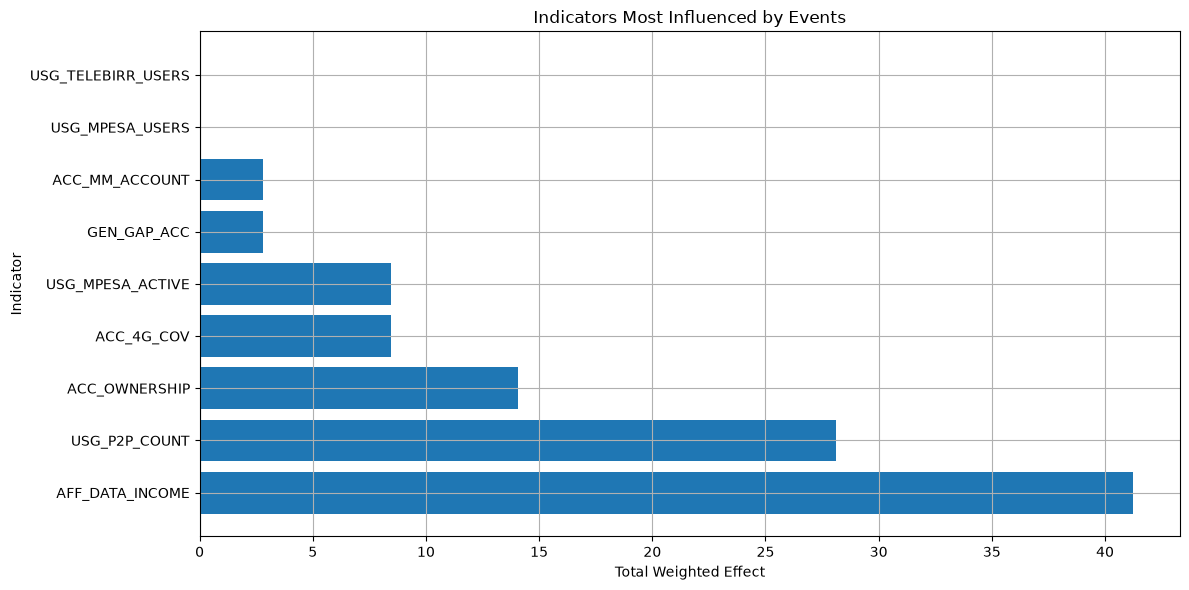

figures\indicator_impact_summary.png


In [49]:
plt.figure(figsize=(12,6))

plt.barh(
    indicator_summary["related_indicator"],
    indicator_summary["total_effect"]
)

plt.xlabel("Total Weighted Effect")

plt.ylabel("Indicator")

plt.title("Indicators Most Influenced by Events")

plt.tight_layout()

indicator_path = save_figure(
    "indicator_impact_summary.png"
)

plt.show()

print(indicator_path)

In [50]:
top_positive = event_summary.iloc[0]

top_negative = event_summary.iloc[-1]

largest_indicator = indicator_summary.iloc[0]

print("Top Positive Event")
display(top_positive)

print("Top Negative Event")
display(top_negative)

print("Most Sensitive Indicator")
display(largest_indicator)

Top Positive Event


event_name              Foreign Exchange Liberalization
event_category                                   policy
number_of_indicators                                  1
average_effect                                     22.5
total_effect                                       22.5
average_confidence                                  1.0
Name: 2, dtype: object

Top Negative Event


event_name              M-Pesa Ethiopia Launch
event_category                  product_launch
number_of_indicators                         2
average_effect                          2.8125
total_effect                            2.8125
average_confidence                       0.875
Name: 4, dtype: object

Most Sensitive Indicator


related_indicator    AFF_DATA_INCOME
average_effect                 13.75
total_effect                   41.25
events_affecting                   3
Name: 3, dtype: object

In [51]:
commit_2_checks = {
    "event_summary_created": not event_summary.empty,
    "indicator_summary_created": not indicator_summary.empty,
    "ranking_plot_saved": event_ranking_path.exists(),
    "indicator_plot_saved": indicator_path.exists(),
    "positive_event_identified": (
        event_summary["total_effect"].notna().any()
    ),
    "indicator_scores_available": (
        indicator_summary["total_effect"].notna().any()
    )
}

validation = pd.DataFrame(
    commit_2_checks.items(),
    columns=[
        "validation_check",
        "passed"
    ]
)

display(validation)

assert validation["passed"].all()

print("Commit 2 completed successfully.")

,validation_check,passed
0,event_summary_created,True
1,indicator_summary_created,True
2,ranking_plot_saved,True
3,indicator_plot_saved,True
4,positive_event_identified,True
5,indicator_scores_available,True


Commit 2 completed successfully.


## Forecasting Dataset Preparation

This section prepares a clean dataset for subsequent forecasting models by combining historical financial inclusion observations with engineered event-impact features. The outputs generated here will support predictive modeling in Task 4 and interactive visualization in Task 5.

In [52]:
forecast_df = observations.copy()

forecast_df["analysis_year"] = (
    forecast_df["observation_date"]
    .dt.year
    .fillna(
        pd.to_numeric(
            forecast_df["fiscal_year"],
            errors="coerce"
        )
    )
)

forecast_df = forecast_df.dropna(
    subset=["analysis_year"]
)

forecast_df["analysis_year"] = (
    forecast_df["analysis_year"]
    .astype(int)
)

forecast_df = forecast_df.sort_values(
    [
        "indicator_code",
        "analysis_year"
    ]
)

forecast_df[
    [
        "record_id",
        "indicator_code",
        "indicator",
        "analysis_year",
        "value_numeric"
    ]
].head()

,record_id,indicator_code,indicator,analysis_year,value_numeric
8,REC_0009,ACC_4G_COV,4G Population Coverage,2023,37.5
9,REC_0010,ACC_4G_COV,4G Population Coverage,2025,70.8
11,REC_0012,ACC_FAYDA,Fayda Digital ID Enrollment,2024,8000000.0
12,REC_0013,ACC_FAYDA,Fayda Digital ID Enrollment,2025,12000000.0
13,REC_0014,ACC_FAYDA,Fayda Digital ID Enrollment,2025,15000000.0


In [53]:
events["event_year"] = (
    pd.to_datetime(
        events["period_start"],
        errors="coerce"
    )
    .dt.year
)

event_counts = (
    events.groupby("event_year")
    .size()
    .rename("event_count")
    .reset_index()
)

forecast_df = forecast_df.merge(
    event_counts,
    left_on="analysis_year",
    right_on="event_year",
    how="left"
)

forecast_df["event_count"] = (
    forecast_df["event_count"]
    .fillna(0)
)

forecast_df.drop(
    columns=["event_year"],
    inplace=True,
    errors="ignore"
)

forecast_df.head()

,category,collected_by,collection_date,comparable_country,confidence,evidence_basis,fiscal_year,gender,impact_direction,impact_estimate,impact_magnitude,indicator,indicator_code,indicator_direction,lag_months,location,notes,observation_date,original_text,parent_id,period_end,period_start,pillar,record_id,record_type,region,related_indicator,relationship_type,source_name,source_type,source_url,unit,value_numeric,value_text,value_type,analysis_year,event_count
0,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,FY2022/23,all,NaN,NaN,<NA>,4G Population Coverage,ACC_4G_COV,higher_better,<NA>,national,NaN,2023-06-30,Before major expansion,NaN,NaT,NaT,ACCESS,REC_0009,observation,NaN,NaN,NaN,Ethio Telecom LEAD Report,operator,https://www.ethiotelecom.et/,%,37.5,NaN,percentage,2023,0.0
1,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,FY2024/25,all,NaN,NaN,<NA>,4G Population Coverage,ACC_4G_COV,higher_better,<NA>,national,NaN,2025-06-30,Major infrastructure investment,NaN,NaT,NaT,ACCESS,REC_0010,observation,NaN,NaN,NaN,Ethio Telecom LEAD Report,operator,https://www.ethiotelecom.et/,%,70.8,NaN,percentage,2025,0.0
2,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2024,all,NaN,NaN,<NA>,Fayda Digital ID Enrollment,ACC_FAYDA,higher_better,<NA>,national,NaN,2024-08-15,NaN,NaN,NaT,NaT,ACCESS,REC_0012,observation,NaN,NaN,NaN,Fayda Official,regulator,https://www.id.gov.et/,people,8000000.0,NaN,count,2024,0.0
3,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2025,all,NaN,NaN,<NA>,Fayda Digital ID Enrollment,ACC_FAYDA,higher_better,<NA>,national,NaN,2025-02-28,NaN,NaN,NaT,NaT,ACCESS,REC_0013,observation,NaN,NaN,NaN,World Bank,research,NaN,people,12000000.0,NaN,count,2025,0.0
4,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2025,all,NaN,NaN,<NA>,Fayda Digital ID Enrollment,ACC_FAYDA,higher_better,<NA>,national,NaN,2025-05-15,NaN,NaN,NaT,NaT,ACCESS,REC_0014,observation,NaN,NaN,NaN,ID4Africa Conference,regulator,https://www.id.gov.et/,people,15000000.0,NaN,count,2025,0.0


In [56]:
event_impact_data["event_year"] = (
    pd.to_datetime(
        event_impact_data["event_date"],
        errors="coerce"
    )
    .dt.year
)

In [57]:
yearly_effect = (
    event_impact_data
    .groupby("event_year")
    .agg(
        average_event_effect=(
            "weighted_effect",
            "mean"
        )
    )
    .reset_index()
)

forecast_df = forecast_df.merge(
    yearly_effect,
    left_on="analysis_year",
    right_on="event_year",
    how="left"
)

forecast_df["average_event_effect"] = (
    forecast_df["average_event_effect"]
    .fillna(0)
)

forecast_df.drop(
    columns=["event_year"],
    inplace=True,
    errors="ignore"
)

forecast_df.head()

,category,collected_by,collection_date,comparable_country,confidence,evidence_basis,fiscal_year,gender,impact_direction,impact_estimate,impact_magnitude,indicator,indicator_code,indicator_direction,lag_months,location,notes,observation_date,original_text,parent_id,period_end,period_start,pillar,record_id,record_type,region,related_indicator,relationship_type,source_name,source_type,source_url,unit,value_numeric,value_text,value_type,analysis_year,event_count,average_event_effect
0,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,FY2022/23,all,NaN,NaN,<NA>,4G Population Coverage,ACC_4G_COV,higher_better,<NA>,national,NaN,2023-06-30,Before major expansion,NaN,NaT,NaT,ACCESS,REC_0009,observation,NaN,NaN,NaN,Ethio Telecom LEAD Report,operator,https://www.ethiotelecom.et/,%,37.5,NaN,percentage,2023,0.0,0.0
1,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,FY2024/25,all,NaN,NaN,<NA>,4G Population Coverage,ACC_4G_COV,higher_better,<NA>,national,NaN,2025-06-30,Major infrastructure investment,NaN,NaT,NaT,ACCESS,REC_0010,observation,NaN,NaN,NaN,Ethio Telecom LEAD Report,operator,https://www.ethiotelecom.et/,%,70.8,NaN,percentage,2025,0.0,0.0
2,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2024,all,NaN,NaN,<NA>,Fayda Digital ID Enrollment,ACC_FAYDA,higher_better,<NA>,national,NaN,2024-08-15,NaN,NaN,NaT,NaT,ACCESS,REC_0012,observation,NaN,NaN,NaN,Fayda Official,regulator,https://www.id.gov.et/,people,8000000.0,NaN,count,2024,0.0,0.0
3,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2025,all,NaN,NaN,<NA>,Fayda Digital ID Enrollment,ACC_FAYDA,higher_better,<NA>,national,NaN,2025-02-28,NaN,NaN,NaT,NaT,ACCESS,REC_0013,observation,NaN,NaN,NaN,World Bank,research,NaN,people,12000000.0,NaN,count,2025,0.0,0.0
4,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2025,all,NaN,NaN,<NA>,Fayda Digital ID Enrollment,ACC_FAYDA,higher_better,<NA>,national,NaN,2025-05-15,NaN,NaN,NaT,NaT,ACCESS,REC_0014,observation,NaN,NaN,NaN,ID4Africa Conference,regulator,https://www.id.gov.et/,people,15000000.0,NaN,count,2025,0.0,0.0


In [55]:
event_impact_data.columns.tolist()

['category',
 'collected_by',
 'collection_date',
 'comparable_country',
 'confidence',
 'evidence_basis',
 'fiscal_year',
 'gender',
 'impact_direction',
 'impact_estimate',
 'impact_magnitude',
 'indicator',
 'indicator_code',
 'indicator_direction',
 'lag_months',
 'location',
 'notes',
 'observation_date',
 'original_text',
 'parent_id',
 'period_end',
 'period_start',
 'pillar',
 'record_id',
 'record_type',
 'region',
 'related_indicator',
 'relationship_type',
 'source_name',
 'source_type',
 'source_url',
 'unit',
 'value_numeric',
 'value_text',
 'value_type',
 'event_id',
 'event_name',
 'event_category',
 'event_date',
 'event_description',
 'event_source',
 'event_source_url',
 'direction_score',
 'confidence_weight',
 'signed_magnitude',
 'weighted_effect',
 'magnitude_weight',
 'signed_estimate']

In [61]:
forecast_output = (
    processed_path
    / "forecast_dataset.csv"
)

forecast_df.to_csv(
    forecast_output,
    index=False
)

print(forecast_output)

data\processed\forecast_dataset.csv


In [59]:
figures_path

WindowsPath('figures')

In [60]:
from pathlib import Path

data_path = Path("data")
processed_path = data_path / "processed"
figures_path = Path("figures")

processed_path.mkdir(parents=True, exist_ok=True)
figures_path.mkdir(parents=True, exist_ok=True)

print("Processed folder:", processed_path)
print("Figures folder:", figures_path)

Processed folder: data\processed
Figures folder: figures


In [62]:
event_summary.to_csv(
    processed_path / "event_summary.csv",
    index=False
)

indicator_summary.to_csv(
    processed_path / "indicator_summary.csv",
    index=False
)

association_matrix_display.to_csv(
    processed_path / "association_matrix.csv"
)

print("Dashboard datasets exported.")

Dashboard datasets exported.


In [63]:
commit_3_checks = {
    "forecast_dataset_created":
        not forecast_df.empty,

    "forecast_dataset_saved":
        forecast_output.exists(),

    "event_summary_saved":
        (processed_path / "event_summary.csv").exists(),

    "indicator_summary_saved":
        (processed_path / "indicator_summary.csv").exists(),

    "association_matrix_saved":
        (processed_path / "association_matrix.csv").exists(),

    "contains_event_feature":
        "event_count" in forecast_df.columns,

    "contains_effect_feature":
        "average_event_effect" in forecast_df.columns,

    "contains_target":
        "value_numeric" in forecast_df.columns
}

validation = pd.DataFrame(
    commit_3_checks.items(),
    columns=[
        "validation_check",
        "passed"
    ]
)

display(validation)

assert validation["passed"].all()

print(
    "Task 3 completed successfully."
)

,validation_check,passed
0,forecast_dataset_created,True
1,forecast_dataset_saved,True
2,event_summary_saved,True
3,indicator_summary_saved,True
4,association_matrix_saved,True
5,contains_event_feature,True
6,contains_effect_feature,True
7,contains_target,True


Task 3 completed successfully.


## Task 3 Summary

Task 3 successfully transformed the enriched financial inclusion data into a forecasting-ready analytical dataset. Historical observations were integrated with engineered event features, including annual event counts and average event impacts. The event-indicator association matrix, summary statistics, and processed forecasting dataset were exported for downstream forecasting and dashboard development. These outputs provide the foundation for predictive modeling in Task 4 and visualization in Task 5.